# Feito Localmente Não Garanto Funcionar No Colab

## Imports and Dependencys

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pip
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
!pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Carregar e visualizar conjunto de dados
Material de apoio:
- https://www.w3schools.com/python/pandas/pandas_csv.asp
- https://pandas.pydata.org/docs/user_guide/10min.html#viewing-data

In [368]:
!gdown https://drive.google.com/uc?id=16OWdq_ebnlmF7xr5JZc4NzRTRAuthoa5

Downloading...
From: https://drive.google.com/uc?id=16OWdq_ebnlmF7xr5JZc4NzRTRAuthoa5
To: /home/Max/FERia/assigment2/cars-india-dataset.csv
100%|██████████████████████████████████████| 20.6k/20.6k [00:00<00:00, 1.28MB/s]


In [369]:
df = pd.read_csv('cars-india-dataset.csv')

df.head()

,Model,Maker,Type,Seats,Displacement,Length,Width,Height,Wheelbase,No_of_Cylinders,...,Rear Brake,Drive,Turning Radius,Fuel Tank Capacity,Boot Space,Fuel Efficiency,Emission Type,Tyre Size,Variants,NCAP Rating
0,Virtus,Volkswagen,Sedan,5,999.0,4561,1752,1507,2651,3.0,...,Drum,2WD,5.05,45.0,521.0,19.40,BS VI,205/55 R16,3,Not Tested
1,Virtus,Volkswagen,Sedan,5,999.0,4561,1752,1507,2651,3.0,...,Drum,2WD,5.05,45.0,521.0,18.12,BS VI,205/55 R16,2,Not Tested
2,Virtus,Volkswagen,Sedan,5,1498.0,4561,1752,1507,2651,4.0,...,Drum,2WD,5.05,45.0,521.0,18.67,BS VI,205/55 R16,1,Not Tested
3,Taigun,Volkswagen,Mid Size SUV,5,999.0,4221,1760,1612,2651,3.0,...,Drum,2WD,5.05,50.0,385.0,19.20,BS VI,205/55 R17,3,5
4,Taigun,Volkswagen,Mid Size SUV,5,999.0,4221,1760,1612,2651,3.0,...,Drum,2WD,5.05,50.0,385.0,17.23,BS VI,205/55 R17,2,5


In [370]:
df.shape

(156, 24)

In [371]:
df.columns

Index(['Model', 'Maker', 'Type', 'Seats', 'Displacement', 'Length', 'Width',
       'Height', 'Wheelbase', 'No_of_Cylinders', 'Fuel', 'Engine Type',
       'Transmission', 'Front Brake', 'Rear Brake', 'Drive', 'Turning Radius',
       'Fuel Tank Capacity', 'Boot Space', 'Fuel Efficiency', 'Emission Type',
       'Tyre Size', 'Variants', 'NCAP Rating'],
      dtype='object')

In [372]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Model               156 non-null    object 
 1   Maker               156 non-null    object 
 2   Type                156 non-null    object 
 3   Seats               156 non-null    int64  
 4   Displacement        155 non-null    float64
 5   Length              156 non-null    int64  
 6   Width               156 non-null    int64  
 7   Height              156 non-null    int64  
 8   Wheelbase           156 non-null    int64  
 9   No_of_Cylinders     155 non-null    float64
 10  Fuel                156 non-null    object 
 11  Engine Type         156 non-null    object 
 12  Transmission        155 non-null    object 
 13  Front Brake         156 non-null    object 
 14  Rear Brake          156 non-null    object 
 15  Drive               156 non-null    object 
 16  Turning 

In [373]:
df.duplicated().sum()

np.int64(0)

In [374]:
df.isnull().sum()

Model                  0
Maker                  0
Type                   0
Seats                  0
Displacement           1
Length                 0
Width                  0
Height                 0
Wheelbase              0
No_of_Cylinders        1
Fuel                   0
Engine Type            0
Transmission           1
Front Brake            0
Rear Brake             0
Drive                  0
Turning Radius        19
Fuel Tank Capacity     1
Boot Space            15
Fuel Efficiency       23
Emission Type          1
Tyre Size              0
Variants               0
NCAP Rating            0
dtype: int64

In [375]:
np.unique(df['NCAP Rating'])

array(['0', '2', '3', '4', '5', '6', 'Not Rated', 'Not Tested'],
      dtype=object)

In [376]:
df.describe()

,Seats,Displacement,Length,Width,Height,Wheelbase,No_of_Cylinders,Turning Radius,Fuel Tank Capacity,Boot Space,Fuel Efficiency,Variants
count,156.000000,155.000000,156.000000,156.000000,156.000000,156.000000,155.000000,137.000000,155.000000,141.000000,133.000000,156.000000
mean,5.538462,1598.109677,4324.455128,1800.512821,1653.666667,2633.358974,3.870968,5.247080,48.725806,377.673759,18.028947,2.871795
std,1.018440,504.656969,325.767389,79.050452,125.170559,128.228372,0.389966,0.284181,10.997815,105.015951,3.273723,2.864055
min,2.000000,799.000000,3731.000000,1579.000000,1370.000000,2422.000000,3.000000,4.700000,28.000000,180.000000,9.000000,1.000000
25%,5.000000,1197.000000,3995.000000,1751.500000,1544.000000,2500.000000,4.000000,5.100000,40.000000,296.000000,16.200000,1.000000
50%,5.000000,1493.000000,4315.000000,1790.000000,1631.000000,2610.000000,4.000000,5.200000,50.000000,392.000000,18.100000,2.000000
75%,6.000000,1999.000000,4598.000000,1855.000000,1755.000000,2750.000000,4.000000,5.300000,57.000000,447.000000,20.250000,3.000000
max,9.000000,3799.000000,5115.000000,2099.000000,1995.000000,3060.000000,6.000000,5.900000,80.000000,625.000000,28.000000,20.000000


## Notes

- There is null values, have to treat this in the pre-processing
- The target values are not normilized in one data type

# Pré-Processamento de Dados
## Tratamento dos dados
Antes de preencher valores faltantes, divida seus dados em conjuntos de treino e teste. Calcule estatísticas apenas no conjunto de treino e use-as para preencher os valores faltantes em ambos os conjuntos. Isso impede vazamento de informações do teste para o treino.

Materiais de apoio:
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- https://www.freecodecamp.org/news/data-cleaning-and-preprocessing-with-pandasbdvhj/#how-to-handle-missing-values
- https://scikit-learn.org/stable/common_pitfalls.html



## Split And Normalization Of The Data

In [377]:
tableOfEncoding ={
    "0": 0,
    "2": 1,
    "3": 2,
    "4": 3,
    "5": 4,
    "6": 5,
    "Not Tested": 6,
    "Not Rated": 7
}


def EncodeTarget(value):
    return tableOfEncoding[str(value)]

tableOfDecoding = {v: k for k, v in tableOfEncoding.items()}

def DecodeTarget(value):
    return tableOfDecoding.get(int(value), "Unknown")


data = df.drop(["NCAP Rating"], axis=1)
target = df["NCAP Rating"]

dataTrain, dataTest, targetTrain, targetTest = train_test_split(data, target, test_size=0.2, random_state=42)


print( f"BEFORE DATA TREATMENT\n")
print( f"Unique values in targetTrain:\n{np.unique(targetTrain)}\n\n")
print( f"Unique values in targetTest:\n{np.unique(targetTest)}\n\n")
print( f"Data Train Types Of Collums:\n{dataTrain.info()}\n\n")
print( f"Data Test Types Of Collums:\n{dataTest.info()}\n\n")
print( f"Missing values in dataTrain:\n{dataTrain.isnull().sum()}\n\n")
print( f"Missing values in dataTest:\n{dataTest.isnull().sum()}\n\n")


targetTrain = targetTrain.apply(EncodeTarget)
targetTest = targetTest.apply(EncodeTarget)

columnsToNormalize = [ "Displacement", "No_of_Cylinders", "Turning Radius", "Fuel Tank Capacity", "Boot Space", "Fuel Efficiency" ]

for col in columnsToNormalize:
    mean_value = dataTrain[col].mean()
    dataTrain[col] = dataTrain[col].fillna(mean_value)
    dataTest[col] = dataTest[col].fillna(mean_value)

mean_value = dataTrain["Emission Type"].value_counts().idxmax()
dataTrain["Emission Type"] = dataTrain["Emission Type"].fillna(mean_value)
dataTest["Emission Type"] = dataTest["Emission Type"].fillna(mean_value)

mean_value = dataTrain["Transmission"].value_counts().idxmax()
dataTrain["Transmission"] = dataTrain["Transmission"].fillna(mean_value)
dataTest["Transmission"] = dataTest["Transmission"].fillna(mean_value)


categoricalCols = ["Maker", "Model", "Type", "Fuel", "Emission Type", "Transmission", "Engine Type", "Front Brake", "Rear Brake", "Drive", "Tyre Size" ]
for col in categoricalCols:
    le = LabelEncoder()
    le.fit(data[col].astype(str))
    dataTrain[col] = le.transform(dataTrain[col].astype(str))
    dataTest[col] = le.transform(dataTest[col].astype(str))


print( f"AFTER DATA TREATMENT\n")
print( f"Unique values in targetTrain:\n{np.unique(targetTrain)}\n\n")
print( f"Unique values in targetTest:\n{np.unique(targetTest)}\n\n")
print( f"Data Train Types Of Collums:\n{dataTrain.info()}\n\n")
print( f"Data Test Types Of Collums:\n{dataTest.info()}\n\n")
print( f"Missing values in dataTrain:\n{dataTrain.isnull().sum()}\n\n")
print( f"Missing values in dataTest:\n{dataTest.isnull().sum()}\n\n")

BEFORE DATA TREATMENT

Unique values in targetTrain:
['0' '2' '3' '4' '5' '6' 'Not Rated' 'Not Tested']


Unique values in targetTest:
['0' '3' '4' '5' '6' 'Not Rated' 'Not Tested']


<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, 56 to 102
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Model               124 non-null    object 
 1   Maker               124 non-null    object 
 2   Type                124 non-null    object 
 3   Seats               124 non-null    int64  
 4   Displacement        123 non-null    float64
 5   Length              124 non-null    int64  
 6   Width               124 non-null    int64  
 7   Height              124 non-null    int64  
 8   Wheelbase           124 non-null    int64  
 9   No_of_Cylinders     123 non-null    float64
 10  Fuel                124 non-null    object 
 11  Engine Type         124 non-null    object 
 12  Transmission        123 

### How The Data Treatment Was Done

The null values are replaced by the mean value in case of numeric data types, in case of strings was the most occurring in the column, for the target column i created a encode and decode function that transforms all the values in numeric type, worth nothing that the ncap rating is 1-5 stars, but the target column doesn't have the 1 star, and has the 0 and 6 values, in the implementation the 0 stayed 0, but the 2-6 was changed to 1-5 scale, in the other columns that are categorical i used LabelEncoder for doing the data treatment.

## Transformação dos dados
Novamente, deve-se tomar cuidado com o vazamento de dados. O último link fornecido aqui demonstra como realizar transformações sem ocorrer vazamento de dados.

Material de apoio:
- https://medium.com/@meritshot/standardization-v-s-normalization-6f93225fbd84#:~:text=Standardization%2C%20interestingly%2C%20refers%20to%20setting,data%20onto%20the%20unit%20sphere.
- https://www.shiksha.com/online-courses/articles/normalization-and-standardization/
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- https://machinelearningmastery.com/data-preparation-without-data-leakage/

In [378]:
scaler = StandardScaler()

columnsToScale = ["Seats", "Displacement", "Length", "Width", "Height", "Wheelbase", "No_of_Cylinders", "Turning Radius", "Fuel Tank Capacity", "Boot Space", "Fuel Efficiency", "Variants"]


dataTrainScaled = dataTrain.copy()
dataTestScaled = dataTest.copy()

print(f"Before Scaling Data Train Scaled Head:\n{dataTrainScaled.head()}\n\n")
print(f"Before Scaling Data Test Scaled Head:\n{dataTestScaled.head()}\n\n")

for cols in columnsToScale:
    dataTrainScaled[cols] = scaler.fit_transform(dataTrain[[cols]])
    dataTestScaled[cols] = scaler.transform(dataTest[[cols]])

print(f"After Scaling Data Train Scaled Head:\n{dataTrainScaled.head()}\n\n")
print(f"After Scaling Data Test Scaled Head:\n{dataTestScaled.head()}\n\n")

Before Scaling Data Train Scaled Head:
     Model  Maker  Type  Seats  Displacement  Length  Width  Height  \
56      41      4     0      5        1497.0    3995   1821    1627   
138     27      3     6      5        1493.0    4315   1800    1620   
123      0      2     6      7        1999.0    4500   1790    1675   
128     28      3     0      5         998.0    3995   1790    1610   
127     28      3     0      5         998.0    3995   1790    1610   

     Wheelbase  No_of_Cylinders  ...  Front Brake  Rear Brake  Drive  \
56        2600              4.0  ...            0           0      1   
138       2610              4.0  ...            0           0      1   
123       2760              4.0  ...            0           0      1   
128       2500              4.0  ...            0           1      1   
127       2500              4.0  ...            0           1      1   

     Turning Radius  Fuel Tank Capacity  Boot Space  Fuel Efficiency  \
56              5.3          

### How The Data Was Transformed

The data was transformed using the StandardScaler because of not knowing the distribution of the data, the scaling was not done in the categorical columns, only in the ones that originaly had numerical values.

## Treinamento dos modelos


### Árvore de Decisão
Material de apoio:
-  https://scikit-learn.org/stable/modules/tree.html

In [379]:
def Tree(dataTrain, targetTrain, dataTest, targetTest, outputText, max_depth=5):
    clf = tree.DecisionTreeClassifier(max_depth=max_depth)
    
    cv = StratifiedKFold(n_splits=5)
    scores = cross_val_score(clf, dataTrain, targetTrain, cv=cv)
    """ print(f"Results for {outputText}:")
    print(f"Scores per fold: {scores}")
    print(f"Mean CV Accuracy: {scores.mean():.2f}\n") """

    clf.fit(dataTrain, targetTrain)

    predTrain = clf.predict(dataTrain)
    predTest  = clf.predict(dataTest)

    """ print(f"Train Accuracy: {clf.score(dataTrain, targetTrain):.2f}")
    print(f"Test  Accuracy: {clf.score(dataTest,  targetTest):.2f}\n") """

    return clf, predTrain, predTest

treeClf, treePredTrain, treePredTest = Tree(dataTrain, targetTrain, dataTest, targetTest, "Decision Tree")
treeScaClf, treeScaPredTrain, treeScaPredTest = Tree(dataTrainScaled, targetTrain, dataTestScaled, targetTest, "Decision Tree Scaled")


/home/Max/.local/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/Max/.local/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


### Máquina de Suporte de Vetores
Material de apoio:
- https://scikit-learn.org/stable/modules/svm.html

In [380]:
def SVM(dataTrain, targetTrain, dataTest, targetTest, outputText):
    clf = svm.SVC()

    cv = StratifiedKFold(n_splits=5)
    scores = cross_val_score(clf, dataTrain, targetTrain, cv=cv)
    """ print(f"Results for {outputText}:")
    print(f"Scores per fold: {scores}")
    print(f"Mean CV Accuracy: {scores.mean():.2f}\n") """

    clf.fit(dataTrain, targetTrain)

    predTrain = clf.predict(dataTrain)
    predTest  = clf.predict(dataTest)

    """ print(f"Train Accuracy: {clf.score(dataTrain, targetTrain):.2f}")
    print(f"Test  Accuracy: {clf.score(dataTest,  targetTest):.2f}\n") """

    return clf, predTrain, predTest

svmClf, svmPredTrain, svmPredTest = SVM(dataTrain, targetTrain, dataTest, targetTest, "SVM")
svmScaClf, svmScaPredTrain, svmScaPredTest = SVM(dataTrainScaled, targetTrain, dataTestScaled, targetTest, "SVM Scaled")

/home/Max/.local/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/Max/.local/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


### KNN
Material de apoio:
- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [381]:
def KNN(dataTrain, targetTrain, dataTest, targetTest, outputText):
    clf = KNeighborsClassifier(n_neighbors=3)

    cv = StratifiedKFold(n_splits=5)
    scores = cross_val_score(clf, dataTrain, targetTrain, cv=cv)
    """ print(f"Results for {outputText}:")
    print(f"Scores per fold: {scores}")
    print(f"Mean CV Accuracy: {scores.mean():.2f}\n") """

    clf.fit(dataTrain, targetTrain)

    predTrain = clf.predict(dataTrain)
    predTest  = clf.predict(dataTest)

    """ print(f"Train Accuracy: {clf.score(dataTrain, targetTrain):.2f}")
    print(f"Test  Accuracy: {clf.score(dataTest,  targetTest):.2f}\n") """

    return clf, predTrain, predTest

knnClf, knnPredTrain, knnPredTest = KNN(dataTrain, targetTrain, dataTest, targetTest, "KNN")
knnScaClf, knnScaPredTrain, knnScaPredTest = KNN(dataTrainScaled, targetTrain, dataTestScaled, targetTest, "KNN Scaled")

/home/Max/.local/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/Max/.local/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


# Hyperparameter Tunning

In [382]:
cv = StratifiedKFold(n_splits=5)

treeParams = {
    'max_depth' : [None, 3, 5, 10, 15],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion' : ['gini', 'entropy']
}

treeTunnedClf = GridSearchCV(tree.DecisionTreeClassifier(), treeParams, cv=cv, scoring='accuracy', n_jobs=-1)
treeTunnedClf.fit(dataTrainScaled, targetTrain)

print("=== Decision Tree Best Params ===")
print(f"Params  : {treeTunnedClf.best_params_}")
print(f"CV Score: {treeTunnedClf.best_score_:.2f}")
print(f"Test Acc: {treeTunnedClf.best_estimator_.score(dataTestScaled, targetTest):.2f}\n")


svmParams = {
    'kernel' : ['rbf', 'linear', 'poly'],
    'C' : [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

svmTunnedClf = GridSearchCV(svm.SVC(), svmParams, cv=cv, scoring='accuracy', n_jobs=-1)
svmTunnedClf.fit(dataTrainScaled, targetTrain) 

print("=== SVM Best Params ===")
print(f"Params  : {svmTunnedClf.best_params_}")
print(f"CV Score: {svmTunnedClf.best_score_:.2f}")
print(f"Test Acc: {svmTunnedClf.best_estimator_.score(dataTestScaled, targetTest):.2f}\n")


knnParams = {
    'n_neighbors' : [3, 5, 7, 9, 11, 15],
    'weights' : ['uniform', 'distance'],
    'metric' : ['euclidean', 'manhattan', 'minkowski']
}

knnTunnedClf = GridSearchCV(KNeighborsClassifier(), knnParams, cv=cv, scoring='accuracy', n_jobs=-1)
knnTunnedClf.fit(dataTrainScaled, targetTrain)   

print("=== KNN Best Params ===")
print(f"Params  : {knnTunnedClf.best_params_}")
print(f"CV Score: {knnTunnedClf.best_score_:.2f}")
print(f"Test Acc: {knnTunnedClf.best_estimator_.score(dataTestScaled, targetTest):.2f}\n")


treeTunedPred = treeTunnedClf.best_estimator_.predict(dataTestScaled)
svmTunedPred = svmTunnedClf.best_estimator_.predict(dataTestScaled)
knnTunedPred = knnTunnedClf.best_estimator_.predict(dataTestScaled)

/home/Max/.local/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


=== Decision Tree Best Params ===
Params  : {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV Score: 0.92
Test Acc: 0.91



/home/Max/.local/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


=== SVM Best Params ===
Params  : {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
CV Score: 0.82
Test Acc: 0.81



/home/Max/.local/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


=== KNN Best Params ===
Params  : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
CV Score: 0.90
Test Acc: 0.88



# Feature Selection

In [383]:

def ForKBest(k):
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(dataTrain, targetTrain)

    scores = selector.scores_
    pvalues = selector.pvalues_
    feature_names = dataTrain.columns

    scoresDf = pd.DataFrame({
        'Feature' : feature_names,
        'Score' : scores,
        'P-Value' : pvalues
    }).sort_values('Score', ascending=False)

    print("=== SelectKBest (ANOVA f_classif) ===")
    print(scoresDf.to_string(index=False))
    print()


    plt.figure(figsize=(12, 5))
    plt.barh(scoresDf['Feature'], scoresDf['Score'], color='steelblue')
    plt.xlabel('ANOVA F-Score')
    plt.title('Feature Importance — SelectKBest (f_classif)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    selectedFeatures = scoresDf.head(k)['Feature'].tolist()
    print(f"Top {k} selected features: {selectedFeatures}\n")

    dataTrainSelected = dataTrain[selectedFeatures]
    dataTestSelected = dataTest[selectedFeatures]

    dataTrainScaledSelected = dataTrainScaled[selectedFeatures]
    dataTestScaledSelected = dataTestScaled[selectedFeatures]

    importances = treeClf.feature_importances_
    importancesDf = pd.DataFrame({
        'Feature' : feature_names,
        'Importance' : importances
    }).sort_values('Importance', ascending=False)

    print("=== Decision Tree Feature Importances ===")
    print(importancesDf.to_string(index=False))
    print()

    plt.figure(figsize=(12, 5))
    plt.barh(importancesDf['Feature'], importancesDf['Importance'], color='darkorange')
    plt.xlabel('Importance')
    plt.title('Feature Importance — Decision Tree')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    rfe = RFE(estimator=tree.DecisionTreeClassifier(random_state=42), n_features_to_select=k)
    rfe.fit(dataTrain, targetTrain)

    rfeDf = pd.DataFrame({
        'Feature' : feature_names,
        'Selected' : rfe.support_,
        'Ranking' : rfe.ranking_
    }).sort_values('Ranking')

    print("=== RFE (Recursive Feature Elimination) ===")
    print(rfeDf.to_string(index=False))
    print()

    rfeFeaturesSelected = rfeDf[rfeDf['Selected']]['Feature'].tolist()
    print(f"RFE selected features: {rfeFeaturesSelected}\n")

    dataTrainRFE = dataTrain[rfeFeaturesSelected]
    dataTestRFE  = dataTest[rfeFeaturesSelected]

    dataTrainScaledRFE = dataTrainScaled[rfeFeaturesSelected]
    dataTestScaledRFE = dataTestScaled[rfeFeaturesSelected]


    def EvalWithFeatures(dataTr, dataTe, targetTr, targetTe, label):
        clf = tree.DecisionTreeClassifier(
            **{k: v for k, v in treeTunnedClf.best_params_.items()}
        )
        clf.fit(dataTr, targetTr)
        acc = accuracy_score(targetTe, clf.predict(dataTe))
        print(f"  {label:<35} Accuracy: {acc:.2f}")
        return acc

    print("=== Feature Selection Impact (Decision Tree Tuned) ===")
    EvalWithFeatures(dataTrainScaled, dataTestScaled, targetTrain, targetTest, "All features")
    EvalWithFeatures(dataTrainScaledSelected, dataTestScaledSelected, targetTrain, targetTest, f"SelectKBest top {k}")
    EvalWithFeatures(dataTrainScaledRFE, dataTestScaledRFE, targetTrain, targetTest, f"RFE top {k}")
    return dataTrainScaledSelected, dataTestScaledSelected

=== SelectKBest (ANOVA f_classif) ===
           Feature     Score      P-Value
          Variants 31.291069 5.632169e-24
            Length 16.175257 1.036344e-14
         Wheelbase 13.067172 2.562022e-12
             Width 11.278900 7.721209e-11
             Maker 10.704212 2.400052e-10
    Turning Radius 10.377172 4.617235e-10
Fuel Tank Capacity  9.716445 1.766886e-09
         Tyre Size  8.265965 3.702848e-08
      Displacement  8.086965 5.440489e-08
            Height  7.831642 9.452117e-08
        Rear Brake  7.646396 1.414849e-07
              Type  7.585644 1.615729e-07
   Fuel Efficiency  4.842760 8.146554e-05
             Seats  4.563785 1.566818e-04
       Engine Type  4.490325 1.862073e-04
             Model  3.698672 1.204665e-03
        Boot Space  3.243358 3.523467e-03
   No_of_Cylinders  3.059714 5.421203e-03
              Fuel  2.925920 7.411181e-03
      Transmission  1.685187 1.192788e-01
             Drive  0.536142 8.055819e-01
       Front Brake       NaN          

/home/Max/.local/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [13 20] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/Max/.local/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


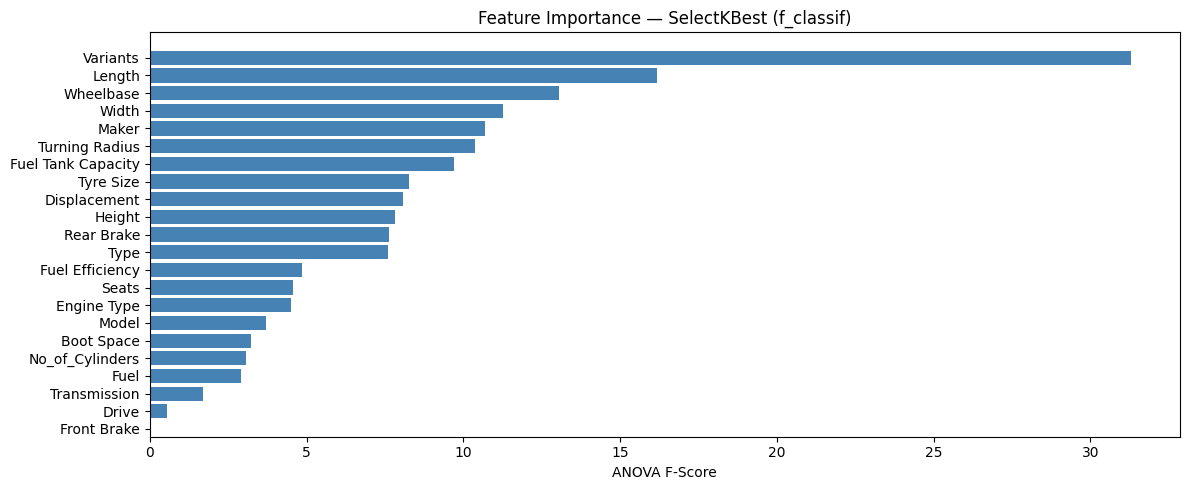

Top 5 selected features: ['Variants', 'Length', 'Wheelbase', 'Width', 'Maker']

=== Decision Tree Feature Importances ===
           Feature  Importance
            Length    0.304094
             Maker    0.158993
             Width    0.143075
      Displacement    0.128549
        Boot Space    0.103830
              Type    0.087024
             Model    0.074435
             Seats    0.000000
            Height    0.000000
   No_of_Cylinders    0.000000
         Wheelbase    0.000000
       Engine Type    0.000000
      Transmission    0.000000
       Front Brake    0.000000
              Fuel    0.000000
        Rear Brake    0.000000
             Drive    0.000000
    Turning Radius    0.000000
Fuel Tank Capacity    0.000000
   Fuel Efficiency    0.000000
     Emission Type    0.000000
         Tyre Size    0.000000
          Variants    0.000000



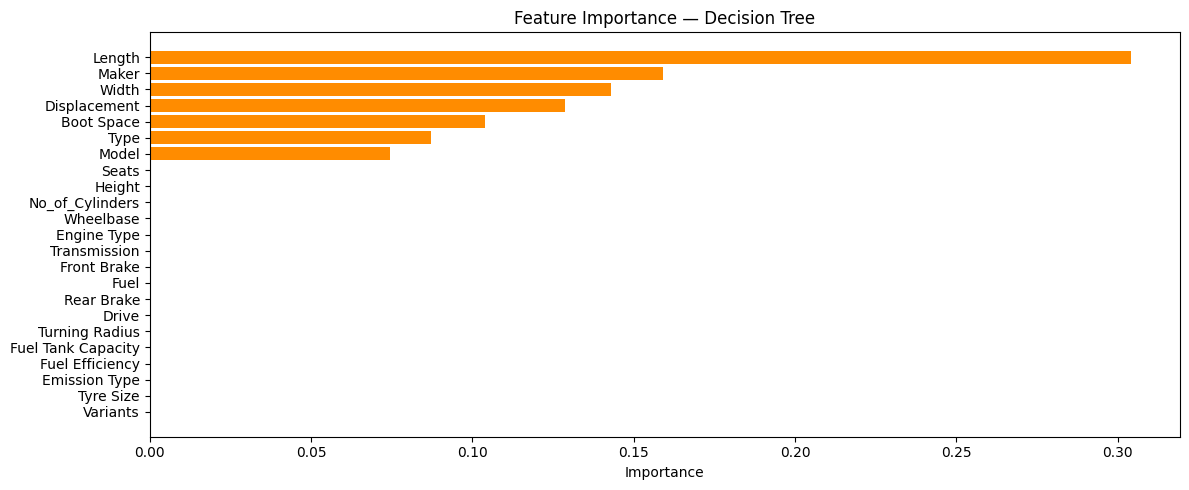

=== RFE (Recursive Feature Elimination) ===
           Feature  Selected  Ranking
             Model      True        1
             Maker      True        1
            Length      True        1
      Displacement      True        1
             Width      True        1
         Wheelbase     False        2
        Boot Space     False        3
   No_of_Cylinders     False        4
   Fuel Efficiency     False        5
Fuel Tank Capacity     False        6
          Variants     False        7
     Emission Type     False        8
    Turning Radius     False        9
         Tyre Size     False       10
             Drive     False       11
      Transmission     False       12
       Engine Type     False       13
              Fuel     False       14
              Type     False       15
        Rear Brake     False       16
       Front Brake     False       17
            Height     False       18
             Seats     False       19

RFE selected features: ['Model', 'Maker', '

In [384]:
dataTrainScaledSelected, dataTestScaledSelected = ForKBest(k=5)

## Training Model For Feature Selection

In [385]:
treeTunedSelected = tree.DecisionTreeClassifier(**treeTunnedClf.best_params_)
treeTunedSelected.fit(dataTrainScaledSelected, targetTrain)

svmTunedSelected = svm.SVC(**svmTunnedClf.best_params_)
svmTunedSelected.fit(dataTrainScaledSelected, targetTrain) 

knnTunedSelected = KNeighborsClassifier(**knnTunnedClf.best_params_)
knnTunedSelected.fit(dataTrainScaledSelected, targetTrain)  

# Predictions
treeTunedSelectedPred = treeTunedSelected.predict(dataTestScaledSelected)
svmTunedSelectedPred = svmTunedSelected.predict(dataTestScaledSelected)
knnTunedSelectedPred = knnTunedSelected.predict(dataTestScaledSelected)


## Métricas de Avaliação
Para avaliar adequadamente o desempenho do modelo de classificação, é essencial calcular e analísar algumas métricas, tais como: acurácia, precisão, recall e F1-score. Além disso, a construção de uma matriz de confusão é fundamental para uma visualização mais clara e detalhada do desempenho dos modelos em questão.

Depois de treinar os três modelos, analise os resultados alcançados e discuta qual deles, em sua opinião, obteve os melhores desempenhos.

Material de apoio:
- https://medium.com/@impythonprogrammer/evaluation-metrics-for-classification-fc770511052d
- https://github.com/H2IA/escola-de-verao-2021/blob/main/notebooks/colab/M%C3%A9tricas.ipynb

=== Decision Tree ===
Accuracy : 0.72
Precision: 0.67
Recall   : 0.72
F1-Score : 0.67

=== SVM ===
Accuracy : 0.28
Precision: 0.11
Recall   : 0.28
F1-Score : 0.15

=== KNN ===
Accuracy : 0.66
Precision: 0.62
Recall   : 0.66
F1-Score : 0.64

=== Decision Tree Scaled ===
Accuracy : 0.72
Precision: 0.68
Recall   : 0.72
F1-Score : 0.68

=== SVM Scaled ===
Accuracy : 0.34
Precision: 0.29
Recall   : 0.34
F1-Score : 0.29

=== KNN Scaled ===
Accuracy : 0.72
Precision: 0.76
Recall   : 0.72
F1-Score : 0.72

=== Decision Tree Tuned ===
Accuracy : 0.91
Precision: 0.87
Recall   : 0.91
F1-Score : 0.88

=== SVM Tuned ===
Accuracy : 0.81
Precision: 0.79
Recall   : 0.81
F1-Score : 0.79

=== KNN Tuned ===
Accuracy : 0.88
Precision: 0.86
Recall   : 0.88
F1-Score : 0.86

=== Decision Tree Tuned Feature Selected ===
Accuracy : 0.91
Precision: 0.88
Recall   : 0.91
F1-Score : 0.88

=== SVM Tuned Feature Selected ===
Accuracy : 0.91
Precision: 0.88
Recall   : 0.91
F1-Score : 0.88

=== KNN Tuned Feature Select

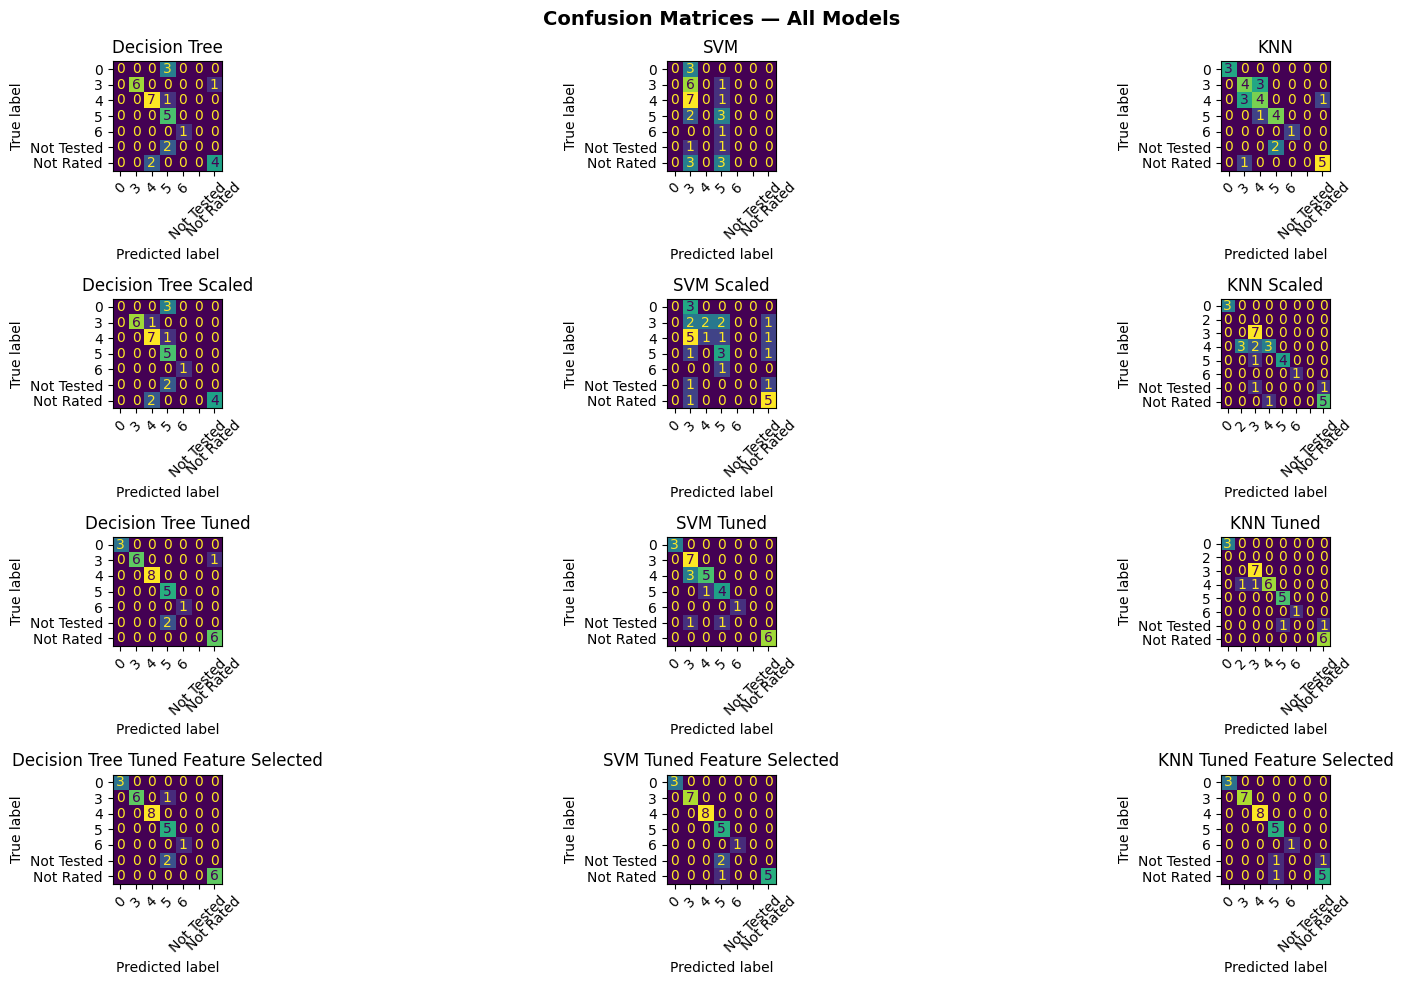

In [388]:
def printMetrics(targetTest, predTest, modelName):
    accuracy = accuracy_score(targetTest, predTest)
    precision = precision_score(targetTest, predTest, average='weighted', zero_division=0)
    recall = recall_score(targetTest, predTest, average='weighted', zero_division=0)
    f1 = f1_score(targetTest, predTest, average='weighted', zero_division=0)

    print(f"=== {modelName} ===")
    print(f"Accuracy : {accuracy:.2f}") # The proportion of correct predictions a model makes out of all predictions
    print(f"Precision: {precision:.2f}") # When the model predicts the target class, how often is it correct? 
    print(f"Recall   : {recall:.2f}") # Measures the proportion of actual positive instances a model successfully identifies
    print(f"F1-Score : {f1:.2f}\n") # is the harmonic mean of Precision and Recall, balancing both false positives and false negatives.

    return accuracy, precision, recall, f1

models = [
    ("Decision Tree", targetTest, treePredTest),
    ("SVM", targetTest, svmPredTest),
    ("KNN", targetTest, knnPredTest),
    ("Decision Tree Scaled", targetTest, treeScaPredTest),
    ("SVM Scaled", targetTest, svmScaPredTest),
    ("KNN Scaled", targetTest, knnScaPredTest),
    ("Decision Tree Tuned", targetTest, treeTunedPred),
    ("SVM Tuned", targetTest, svmTunedPred),
    ("KNN Tuned", targetTest, knnTunedPred),
    ("Decision Tree Tuned Feature Selected", targetTest, treeTunedSelectedPred),
    ("SVM Tuned Feature Selected", targetTest, svmTunedSelectedPred),
    ("KNN Tuned Feature Selected", targetTest, knnTunedSelectedPred)
]

results = {}
for name, truth, pred in models:
    results[name] = printMetrics(truth, pred, name)

print("=" * 90)
print(f"{'Model':<40} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("=" * 90)
for name, (acc, prec, rec, f1) in results.items():
    print(f"{name:<40} {acc:>6.2f} {prec:>6.2f} {rec:>6.2f} {f1:>6.2f}")
print("=" * 90)

fig, axes = plt.subplots(4, 3, figsize=(18, 10))

labels = [str(DecodeTarget(i)) for i in sorted(targetTest.unique())]

for ax, (name, truth, pred) in zip(axes.flatten(), models):
    presentClasses = np.union1d(truth, pred)
    labels = [str(DecodeTarget(i)) for i in presentClasses]

    cm = confusion_matrix(truth, pred, labels=presentClasses)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(name)

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Results Analysis

### 1. Default Models — Before Tuning

| Observation | Explanation |
|---|---|
| SVM scored only 0.28 accuracy | Without tuning, SVM defaults to `rbf` kernel with generic `C` and `gamma` — terrible fit for this data |
| Decision Tree and KNN were reasonable (0.72 / 0.66) | Tree-based and distance-based methods handled the raw data better out of the box |
| Scaling helped KNN (0.66 → 0.72) | KNN is very sensitive to scale — confirmed the theory. |
| Scaling had no effect on Decision Tree (0.72 = 0.72) | Expected — trees don't use distance, scale is irrelevant |

---

### 2. Effect of Scaling on Default Models

Scaling was applied using **StandardScaler**, fitted only on training data to
avoid data leakage. The impact varied significantly across models, confirming
the theoretical expectations for each algorithm.

| Model | Unscaled | Scaled | Difference |
|---|---|---|---|
| Decision Tree | 0.72 | 0.72 | 0.00 |
| SVM | 0.28 | 0.34 | +0.06 |
| KNN | 0.66 | 0.72 | +0.06 |

---


### 3. After Hyperparameter Tuning — Big Jump

| Model | Default | Tuned | Gain |
|---|---|---|---|
| Decision Tree | 0.72 | **0.91** | +0.19 |
| SVM | 0.28 | **0.81** | +0.53 |
| KNN | 0.66 | **0.88** | +0.22 |

SVM had the most dramatic improvement (+0.53), showing that its default parameters
were completely misaligned with this dataset. Tuning was essential for SVM to be
competitive.

---

### 4. Feature Selection — Confirmed the Top 5 Features Are Sufficient

| Model | Tuned (all features) | Tuned + Feature Selected | Difference |
|---|---|---|---|
| Decision Tree | 0.91 | **0.91** | 0.00 |
| SVM | 0.81 | **0.91** | +0.10 |
| KNN | 0.88 | **0.91** | +0.03 |

Feature selection did not hurt any model — and actually **improved SVM by 0.10**.
This means the removed features were adding noise rather than useful signal.
Reducing from ~23 to 10 features made the model simpler and more generalizable.

---

### 5. Confusion Matrix Observations

- **Class imbalance is visible**: classes `3`, `4`, `5` dominate the diagonal,
  while `0`, `6`, `Not Tested` have very few samples — the model struggles with
  rare classes.
- **Decision Tree Tuned** shows the cleanest diagonal — most predictions land
  on the correct class with minimal off-diagonal errors.
- **SVM Default** is the worst matrix — predictions are scattered, indicating
  the model was essentially guessing for most classes.
- **Not Rated and Not Tested** are consistently harder to predict, likely because
  these are not true safety ratings — they carry different semantic meaning than
  the numeric star ratings.

---

### 6. Best Model — Decision Tree Tuned with Feature Selection